# Energy: regional demand and Chicago building reports

This notebook answers two different questions:

| Dataset | What one row means | What it can tell us |
|---|---|---|
| EIA / PJM | Electricity demanded across the **whole PJM region during one hour**, in MWh | Regional demand patterns; the target used by our forecasting model |
| Chicago Energy Benchmarking | One property's **annual** reported energy use | How reported building electricity use varies across Chicago community areas |

**PJM is not Chicago alone.** The Chicago dataset covers reporting properties, not every household or building. Its latest published data year may be older than 2026. Neither dataset is made more current by changing a chart label.

Run **Restart Kernel and Run All Cells** using the project's `.venv` kernel. Every table and title below is calculated from the local files. Running this notebook does not download data or retrain the model.

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import sys
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "CLAUDE.md").exists() and (p / "ingestion/energy").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside urban-metrics-forecasting.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from features.energy.engineer import clean_outliers, DEFAULT_MAX_DEMAND

DEMAND_PATH = ROOT / "data/raw/energy/eia_demand_pjm.parquet"
BENCH_PATH = ROOT / "data/raw/energy/chicago_energy_benchmarking.parquet"
for path in (DEMAND_PATH, BENCH_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Run the energy ingestion script first: missing {path.name}")

plt.rcParams.update({"figure.figsize": (11, 4.5), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 13, "axes.labelsize": 10,
                     "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_columns", 12)
NOW = pd.Timestamp.now(tz="UTC")
raw = pd.read_parquet(DEMAND_PATH)
bench_raw = pd.read_parquet(BENCH_PATH)
print(f"Notebook executed: {NOW:%Y-%m-%d %H:%M UTC}")

Notebook executed: 2026-09-02 05:16 UTC


## 1. What data do we actually have?

`period` is the source's UTC hour label; `value` is the energy demanded in that hour. **MWh measures energy**, while MW measures power. Calendar profiles below use Chicago local time (including daylight saving time) for readability, although PJM spans multiple time zones. The model currently uses UTC calendar features.

A file's modification time is shown separately from the dates its records describe. Annual `data_year` means the year of energy use, not the year it was downloaded.

In [ ]:
periods = pd.to_datetime(raw["period"], utc=True, errors="raise")
bench_years = pd.to_numeric(bench_raw["data_year"], errors="coerce")
coverage = pd.DataFrame([
    {"dataset": "PJM hourly demand", "rows": len(raw),
     "records_from": str(periods.min()), "records_through": str(periods.max()),
     "local_file_modified_utc": pd.Timestamp(DEMAND_PATH.stat().st_mtime, unit="s", tz="UTC").isoformat()},
    {"dataset": "Chicago annual building reports", "rows": len(bench_raw),
     "records_from": str(int(bench_years.min())), "records_through": str(int(bench_years.max())),
     "local_file_modified_utc": pd.Timestamp(BENCH_PATH.stat().st_mtime, unit="s", tz="UTC").isoformat()},
]).set_index("dataset")
display(coverage)
latest_year = int(periods.max().year)
benchmark_year = int(bench_years.max())
display(Markdown(f"**PJM observations end at {periods.max():%Y-%m-%d %H:%M UTC}.** "
                 f"Chicago's latest data year in this file is **{benchmark_year}**. "
                 "Any later annual Chicago data are unavailable in this file; no values are projected forward."))
display(raw.head(5))

,rows,records_from,records_through,local_file_modified_utc
dataset,,,,
PJM hourly demand,58468,2020-01-01 00:00:00+00:00,2026-09-02 04:00:00+00:00,2026-09-02T05:12:32.469516039+00:00
Chicago annual building reports,28329,2014,2023,2026-09-02T05:12:32.509479761+00:00


**PJM observations end at 2026-09-02 04:00 UTC.** Chicago's latest data year in this file is **2023**. Any later annual Chicago data are unavailable in this file; no values are projected forward.

,period,respondent,respondent-name,type,type-name,value,value-units
0,2020-01-01 00:00:00,PJM,"PJM Interconnection, LLC",D,Demand,96028.0,megawatthours
1,2020-01-01 01:00:00,PJM,"PJM Interconnection, LLC",D,Demand,93365.0,megawatthours
2,2020-01-01 02:00:00,PJM,"PJM Interconnection, LLC",D,Demand,90573.0,megawatthours
3,2020-01-01 03:00:00,PJM,"PJM Interconnection, LLC",D,Demand,87907.0,megawatthours
4,2020-01-01 04:00:00,PJM,"PJM Interconnection, LLC",D,Demand,85226.0,megawatthours


## 2. Clean demand without hiding missing hours

We reuse the training pipeline's rule: mask nonnumeric/missing, negative, infinite, or at least 300,000 MWh readings. That upper limit is a configurable screening rule, **not a verified physical maximum**; plausible-looking errors below it can remain. Zero is retained to match the training pipeline, but counted for review.

Missing hours stay in the timeline as missing values. We do not fill gaps, invent observations, or remove real peaks just because they are unusual. Duplicate or malformed timestamps stop execution for investigation.

In [ ]:
assert raw["respondent"].eq("PJM").all(), "Expected only PJM demand."
assert raw["type"].eq("D").all(), "Expected demand observations only."
assert raw["value-units"].eq("megawatthours").all(), "Unexpected source units."
values = pd.to_numeric(raw["value"], errors="coerce")
invalid = ~values.between(0, DEFAULT_MAX_DEMAND, inclusive="left")
quality = pd.Series({
    "Raw rows": len(raw),
    "Missing / nonnumeric values": int(values.isna().sum()),
    "Infinite values": int(np.isinf(values).sum()),
    "Finite negative values": int((np.isfinite(values) & (values < 0)).sum()),
    "Finite values at/above screening limit": int((np.isfinite(values) & (values >= DEFAULT_MAX_DEMAND)).sum()),
    "Zero values (retained; review)": int(values.eq(0).sum()),
    "Duplicate UTC timestamps (must be zero)": int(periods.duplicated().sum()),
}, name="count")
demand = clean_outliers(raw, DEFAULT_MAX_DEMAND).set_index("period")["value"]
quality["Inserted missing hours"] = len(demand) - len(raw)
quality["Usable observed hours"] = int(demand.notna().sum())
quality["Missing / masked hours on complete timeline"] = int(demand.isna().sum())
display(quality.to_frame())
print("Examples of source readings excluded from charts:")
display(raw.loc[invalid, ["period", "value", "value-units"]].head(8))
assert demand.index.is_unique
assert demand.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()
assert demand.dropna().between(0, DEFAULT_MAX_DEMAND, inclusive="left").all()

  Masked 118 invalid/missing demand values; inserted 1 missing hours (no interpolation)


,count
Raw rows,58468
Missing / nonnumeric values,115
Infinite values,0
Finite negative values,0
Finite values at/above screening limit,3
Zero values (retained; review),0
Duplicate UTC timestamps (must be zero),0
Inserted missing hours,1
Usable observed hours,58350
Missing / masked hours on complete timeline,119


Examples of source readings excluded from charts:


,period,value,value-units
1615,2020-03-08 07:00:00,NaN,megawatthours
1616,2020-03-08 08:00:00,NaN,megawatthours
1617,2020-03-08 09:00:00,NaN,megawatthours
1618,2020-03-08 10:00:00,NaN,megawatthours
1619,2020-03-08 11:00:00,NaN,megawatthours
1620,2020-03-08 12:00:00,NaN,megawatthours
1621,2020-03-08 13:00:00,NaN,megawatthours
1622,2020-03-08 14:00:00,NaN,megawatthours


In [ ]:
year_rows = []
for year, series in demand.groupby(demand.index.year):
    start = pd.Timestamp(year=int(year), month=1, day=1, tz="UTC")
    stop = pd.Timestamp(year=int(year)+1, month=1, day=1, tz="UTC")
    expected = int((stop-start) / pd.Timedelta(hours=1))
    spans_year = series.index.min() == start and series.index.max() == stop-pd.Timedelta(hours=1)
    year_rows.append({"year": int(year), "hours_in_file_span": len(series),
                      "usable_hours": series.count(), "full_year_hours": expected,
                      "coverage_of_file_span_pct": 100*series.count()/len(series),
                      "period": "full calendar span" if spans_year else "partial calendar span"})
yearly_coverage = pd.DataFrame(year_rows).set_index("year")
display(yearly_coverage.round(2))
# Use the latest full calendar span for seasonal profiles; do not blend a partial year into it.
full_years = yearly_coverage.index[yearly_coverage["period"].eq("full calendar span")]
if len(full_years) == 0:
    raise ValueError("Need a full calendar span for the seasonality comparison.")
PROFILE_YEAR = int(full_years.max())
profile = demand.loc[demand.index.year == PROFILE_YEAR].copy()
local_profile = profile.copy()
local_profile.index = local_profile.index.tz_convert("America/Chicago")
print(f"Seasonal profiles use the {PROFILE_YEAR} UTC calendar span, grouped by Chicago local clock.")

,hours_in_file_span,usable_hours,full_year_hours,coverage_of_file_span_pct,period
year,,,,,
2020,8784,8738,8784,99.48,full calendar span
2021,8760,8757,8760,99.97,full calendar span
2022,8760,8737,8760,99.74,full calendar span
2023,8760,8735,8760,99.71,full calendar span
2024,8784,8762,8784,99.75,full calendar span
2025,8760,8760,8760,100.00,full calendar span
2026,5861,5861,8760,100.00,partial calendar span


Seasonal profiles use the 2025 UTC calendar span, grouped by Chicago local clock.


## 3. Regional demand over time

The daily chart averages hourly energy readings; it is **not a daily energy total**. Days with fewer than 24 valid UTC hours are left blank. The second chart shows how many usable hours each year contains, so partial years and data gaps remain visible.

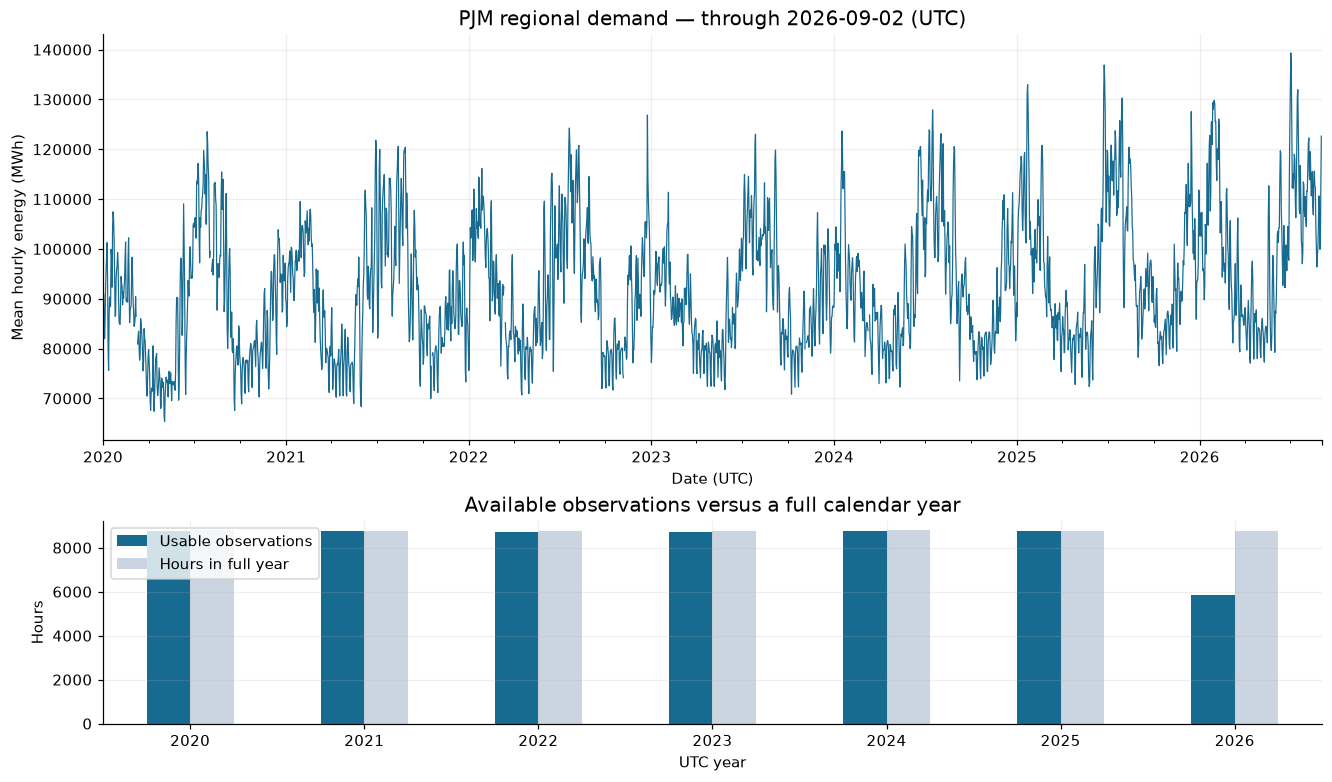

In [ ]:
daily = demand.resample("D").agg(["mean", "count"])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [2, 1]}, layout="constrained")
daily["mean"].where(daily["count"].eq(24)).plot(ax=axes[0], color="#176b91", linewidth=0.8)
axes[0].set(title=f"PJM regional demand — through {demand.index.max():%Y-%m-%d} (UTC)",
            ylabel="Mean hourly energy (MWh)", xlabel="Date (UTC)")
yearly_coverage[["usable_hours", "full_year_hours"]].plot.bar(ax=axes[1], color=["#176b91", "#cbd5e1"], rot=0)
axes[1].set(title="Available observations versus a full calendar year", ylabel="Hours", xlabel="UTC year")
axes[1].legend(["Usable observations", "Hours in full year"], loc="upper left")
plt.show()

## 4. When is demand higher?

These plots describe observations, not model predictions. Each profile uses the latest full calendar span shown above. Shading marks the 10th–90th percentile of observed hourly values, **not a forecast confidence interval**. Temperature, holidays, and activity can affect demand, but these charts alone do not establish the cause of a peak.

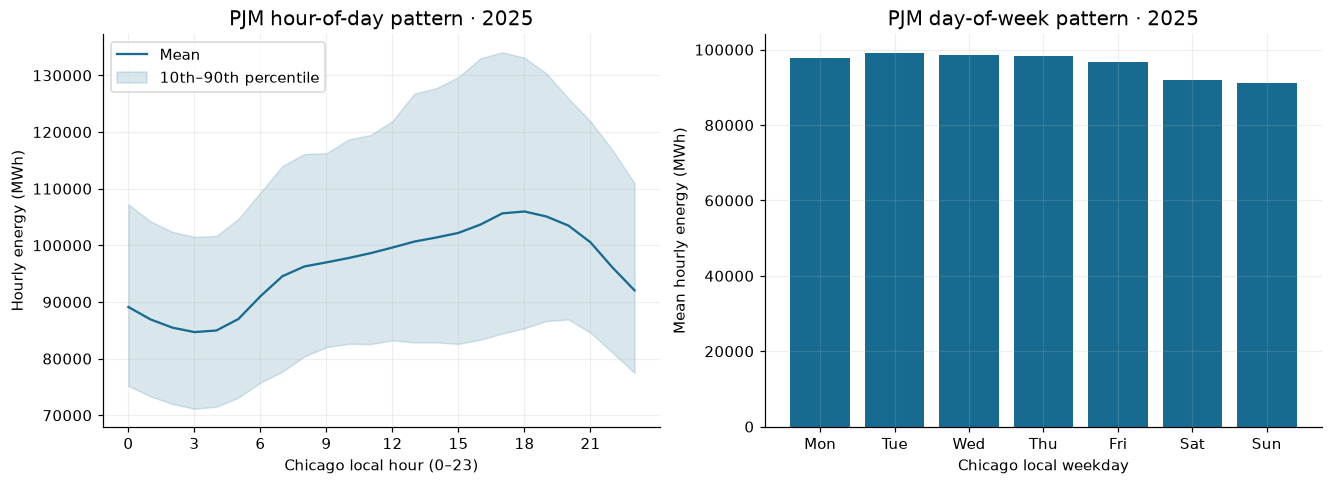

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout="constrained")
hourly = local_profile.groupby(local_profile.index.hour).agg(
    mean="mean", p10=lambda x: x.quantile(.1), p90=lambda x: x.quantile(.9))
axes[0].plot(hourly.index, hourly["mean"], color="#176b91", label="Mean")
axes[0].fill_between(hourly.index, hourly.p10, hourly.p90, color="#176b91", alpha=.16, label="10th–90th percentile")
axes[0].set(title=f"PJM hour-of-day pattern · {PROFILE_YEAR}", xlabel="Chicago local hour (0–23)", ylabel="Hourly energy (MWh)", xticks=range(0,24,3))
axes[0].legend()
weekday = local_profile.groupby(local_profile.index.dayofweek).mean().reindex(range(7))
axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], weekday, color="#176b91")
axes[1].set(title=f"PJM day-of-week pattern · {PROFILE_YEAR}", xlabel="Chicago local weekday", ylabel="Mean hourly energy (MWh)")
plt.show()

## 5. Latest year versus the previous year

Compare **mean hourly demand**, not full-year totals. Only months with a complete UTC calendar span and at least 95% valid hourly observations are plotted. Missing or unfinished months stay blank. This avoids presenting a few hours of a month as a complete month's result. Coverage counts are shown beneath the chart.

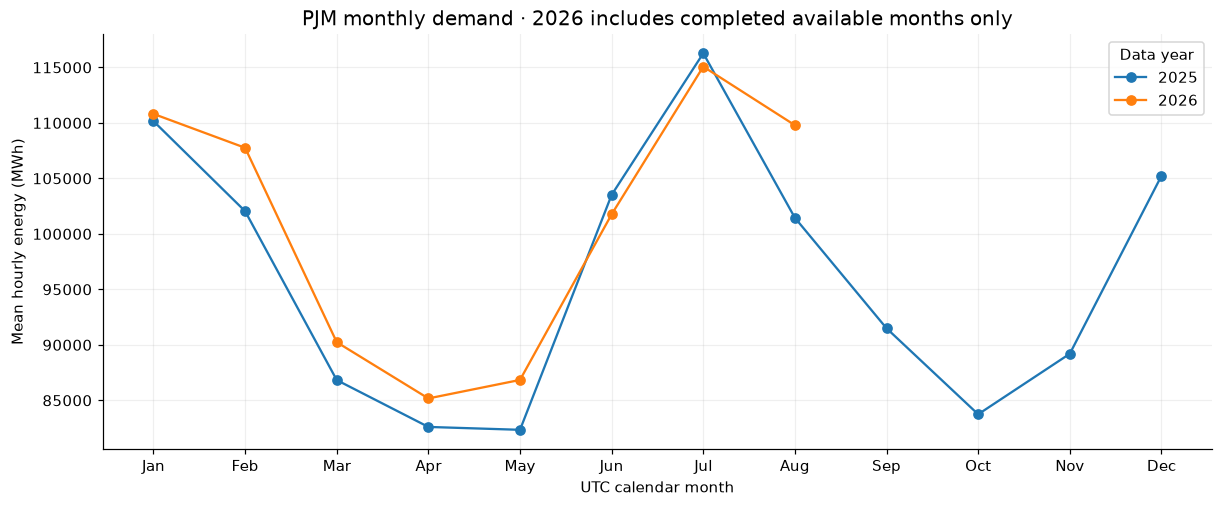

,year,month,usable_hours,expected_hours,coverage_pct,shown
0,2025,1,744,744,100.00,True
1,2025,2,672,672,100.00,True
2,2025,3,744,744,100.00,True
3,2025,4,720,720,100.00,True
4,2025,5,744,744,100.00,True
5,2025,6,720,720,100.00,True
6,2025,7,744,744,100.00,True
7,2025,8,744,744,100.00,True
8,2025,9,720,720,100.00,True
9,2025,10,744,744,100.00,True


In [ ]:
monthly_rows = []
for year in [latest_year - 1, latest_year]:
    for month in range(1, 13):
        start = pd.Timestamp(year=year, month=month, day=1, tz="UTC")
        stop = start + pd.offsets.MonthBegin(1)
        expected = int((stop-start) / pd.Timedelta(hours=1))
        subset = demand.loc[(demand.index >= start) & (demand.index < stop)]
        complete_span = (len(subset) == expected)
        valid = int(subset.count())
        eligible = complete_span and valid / expected >= .95
        monthly_rows.append({"year": year, "month": month, "usable_hours": valid,
                             "expected_hours": expected, "coverage_pct": 100*valid/expected,
                             "shown": eligible, "mean_mwh": subset.mean() if eligible else np.nan})
monthly = pd.DataFrame(monthly_rows)
fig, ax = plt.subplots(figsize=(11,4.5), layout="constrained")
for year, rows in monthly.groupby("year"):
    ax.plot(rows.month, rows.mean_mwh, marker="o", label=str(year))
ax.set(title=f"PJM monthly demand · {latest_year} includes completed available months only",
       xlabel="UTC calendar month", ylabel="Mean hourly energy (MWh)", xticks=range(1,13),
       xticklabels=list(calendar.month_abbr)[1:])
ax.legend(title="Data year")
plt.show()
display(monthly.loc[monthly.usable_hours.gt(0), ["year", "month", "usable_hours", "expected_hours", "coverage_pct", "shown"]].round(2))

## 6. Chicago: one property's annual report is one observation

We select the **latest data year**, normalize community-area spelling/case, and keep missing electricity values missing. Exact duplicate rows are removed and counted; conflicting duplicate property/year reports stop the analysis rather than being added twice.

`electricity_use_kbtu` is electricity expressed in thousands of British thermal units (kBtu), not kWh. `gross_floor_area_buildings_sq_ft` measures building area. A larger total can mean more or larger reporting properties; it does not by itself mean lower efficiency.

These are self-reported records under the [Chicago Energy Benchmarking program](https://catalog.data.gov/dataset/chicago-energy-benchmarking). They are not a census of community energy use and are not currently model inputs.

In [ ]:
# Serialize rows for exact-duplicate detection: location contains nested dictionaries.
row_signatures = pd.Series(bench_raw.to_json(orient="records", lines=True, double_precision=15).splitlines(), index=bench_raw.index)
bench = bench_raw.loc[~row_signatures.duplicated()].copy()
exact_duplicates = len(bench_raw) - len(bench)
bench["data_year"] = pd.to_numeric(bench["data_year"], errors="coerce")
bench["id"] = bench["id"].astype("string").str.strip().replace("", pd.NA)
bench["community_area"] = bench["community_area"].astype("string").str.strip().str.upper().replace("", pd.NA)
for column in ["electricity_use_kbtu", "gross_floor_area_buildings_sq_ft"]:
    bench[column] = pd.to_numeric(bench[column], errors="coerce")
missing_keys = bench[["id", "data_year"]].isna().any(axis=1)
keyed = bench.loc[~missing_keys].copy()
if keyed.duplicated(["id", "data_year"]).any():
    raise ValueError("Conflicting property/year duplicates; inspect source records before aggregation.")
latest = keyed.loc[keyed.data_year.eq(benchmark_year)].copy()
electricity_ok = np.isfinite(latest.electricity_use_kbtu) & latest.electricity_use_kbtu.ge(0)
community_ok = latest.community_area.notna()
reported = latest.loc[electricity_ok & community_ok].copy()
if reported.empty:
    raise ValueError("No usable electricity reports in the latest data year.")
print(f"Latest Chicago data year: {benchmark_year}; not relabeled as {NOW.year}.")
display(pd.Series({"Exact duplicate rows removed (all years)": exact_duplicates,
                   "Rows without property/year key excluded (all years)": int(missing_keys.sum()),
                   "Properties in latest year": len(latest),
                   "Latest-year invalid/missing electricity": int((~electricity_ok).sum()),
                   "Latest-year missing community area": int((~community_ok).sum()),
                   "Latest-year zero electricity reports retained": int(latest.electricity_use_kbtu.eq(0).sum()),
                   "Properties included in community totals": len(reported)}, name="count").to_frame())
community = reported.groupby("community_area").agg(
    electricity_kbtu=("electricity_use_kbtu", "sum"), properties=("id", "nunique"))
community["million_kbtu"] = community.electricity_kbtu / 1_000_000
assert reported.data_year.nunique() == 1
assert not reported.duplicated(["id", "data_year"]).any()
assert np.isclose(community.electricity_kbtu.sum(), reported.electricity_use_kbtu.sum())

Latest Chicago data year: 2023; not relabeled as 2026.


,count
Exact duplicate rows removed (all years),0
Rows without property/year key excluded (all years),0
Properties in latest year,3438
Latest-year invalid/missing electricity,854
Latest-year missing community area,0
Latest-year zero electricity reports retained,0
Properties included in community totals,2584


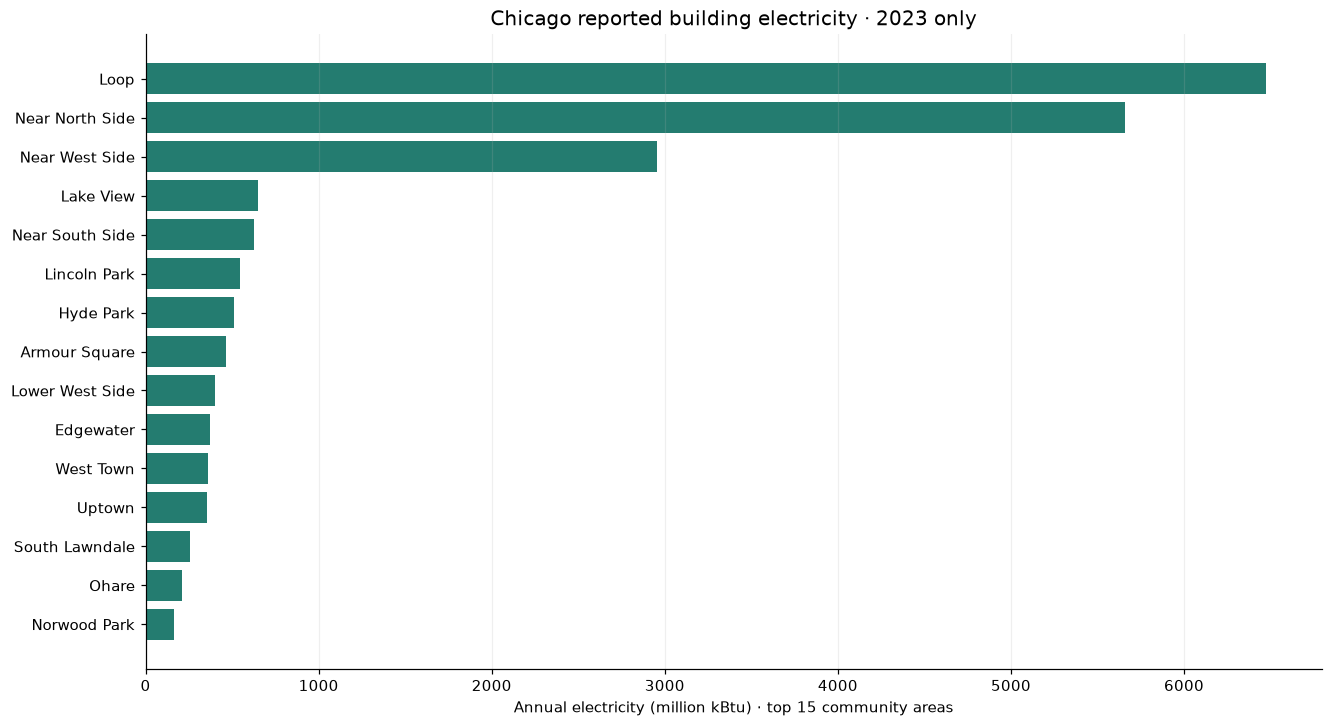

,properties,million_kbtu
community_area,,
LOOP,300,6472.64
NEAR NORTH SIDE,478,5659.78
NEAR WEST SIDE,236,2955.73
LAKE VIEW,154,652.20
NEAR SOUTH SIDE,81,625.58
LINCOLN PARK,124,544.50
HYDE PARK,93,511.15
ARMOUR SQUARE,13,464.52
LOWER WEST SIDE,13,399.77


In [ ]:
top = community.nlargest(15, "electricity_kbtu").sort_values("electricity_kbtu")
fig, ax = plt.subplots(figsize=(12, 6.5), layout="constrained")
ax.barh(top.index.str.title(), top.million_kbtu, color="#247c70")
ax.set(title=f"Chicago reported building electricity · {benchmark_year} only",
       xlabel="Annual electricity (million kBtu) · top 15 community areas", ylabel="")
ax.grid(axis="y", visible=False)
plt.show()
display(community.sort_values("electricity_kbtu", ascending=False)[["properties", "million_kbtu"]].head(15).round(2))

## 7. Account for building size before comparing communities

The chart below divides **total reported electricity by total floor area for the same eligible properties**. This is an area-weighted electricity intensity, not the source's all-fuel site EUI and not an average of individual ratios. Only properties with positive, finite floor area are included. We show the same leading communities as above.

Building use (hospital, office, apartment), occupancy, and reporting quality still differ. This is a descriptive comparison, not an efficiency ranking or a claim about every building in a neighborhood.

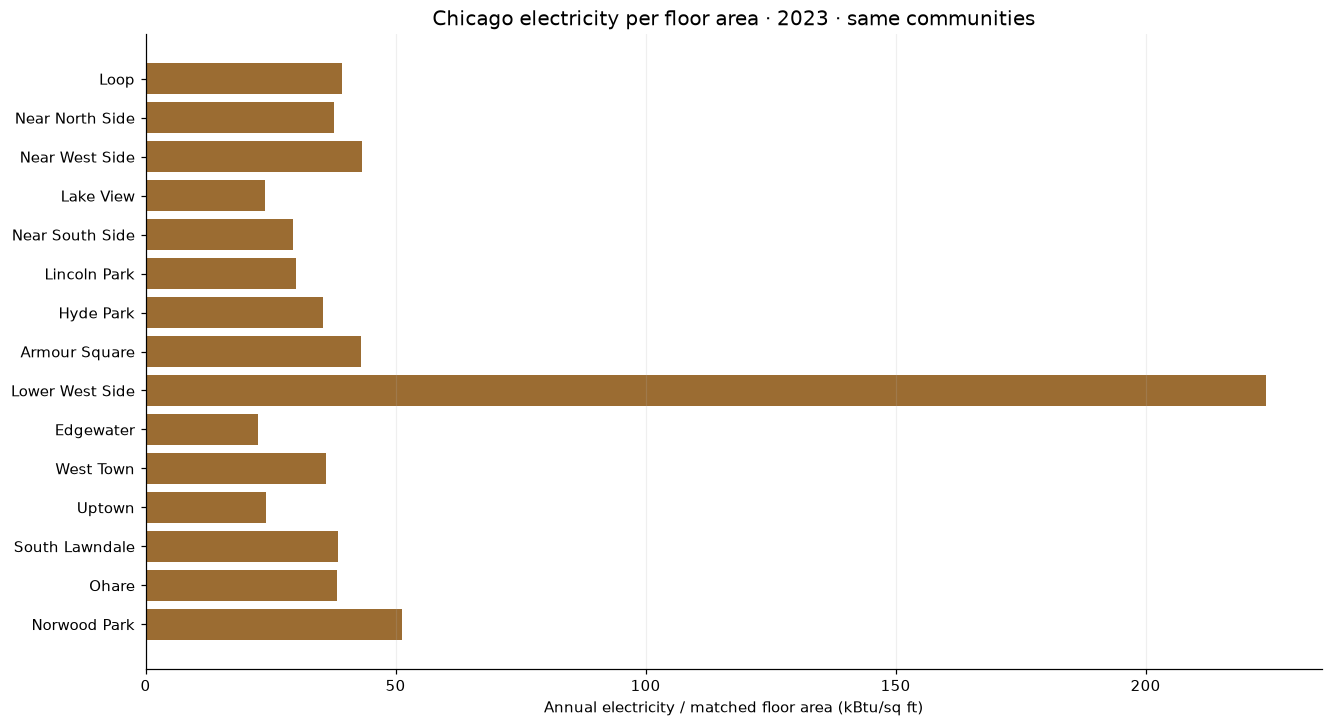

Excluded 0 electricity reports with missing/invalid floor area from intensity only.


,properties,floor_area_sqft,electricity_kbtu_per_sqft
community_area,,,
NORWOOD PARK,19,3236932.0,51.27
OHARE,19,5499842.0,38.27
SOUTH LAWNDALE,17,6670516.0,38.39
UPTOWN,88,14711352.0,24.10
WEST TOWN,75,9967236.0,36.14
EDGEWATER,86,16658147.0,22.39
LOWER WEST SIDE,13,1784371.0,224.04
ARMOUR SQUARE,13,10804318.0,42.99
HYDE PARK,93,14416141.0,35.46


In [ ]:
area_ok = np.isfinite(reported.gross_floor_area_buildings_sq_ft) & reported.gross_floor_area_buildings_sq_ft.gt(0)
matched = reported.loc[area_ok]
intensity = matched.groupby("community_area").agg(
    electricity_kbtu=("electricity_use_kbtu", "sum"),
    floor_area_sqft=("gross_floor_area_buildings_sq_ft", "sum"),
    properties=("id", "nunique"))
intensity["electricity_kbtu_per_sqft"] = intensity.electricity_kbtu / intensity.floor_area_sqft
selected = intensity.reindex(top.index).dropna(subset=["electricity_kbtu_per_sqft"])
fig, ax = plt.subplots(figsize=(12, 6.5), layout="constrained")
ax.barh(selected.index.str.title(), selected.electricity_kbtu_per_sqft, color="#9b6c32")
ax.set(title=f"Chicago electricity per floor area · {benchmark_year} · same communities",
       xlabel="Annual electricity / matched floor area (kBtu/sq ft)", ylabel="")
ax.grid(axis="y", visible=False)
plt.show()
print(f"Excluded {int((~area_ok).sum())} electricity reports with missing/invalid floor area from intensity only.")
display(selected[["properties", "floor_area_sqft", "electricity_kbtu_per_sqft"]].round(2))

## 8. How this relates to training

The forecasting model learns **next-hour PJM demand** from past demand and calendar fields. Training creates lag and rolling-average inputs from this hourly series, then fits XGBoost on an earlier time period and checks it against later observations. The charts in this notebook are exploratory summaries, not proof of forecasting accuracy.

The existing expanded model was trained on 2020–2023, validated on 2024, and tested on 2025. Refreshing the raw file or rerunning this notebook **does not update that saved model**. Model evaluation results remain attached to the data and split used for that training run.

Chicago building totals describe a separate annual dataset. Multiplying regional PJM demand by Chicago community shares would incorrectly allocate the whole region to Chicago. Neighborhood forecasts require a local demand total, a justified allocation method, and local validation.

## Refresh and rerun

From the repository root, download observations through the current UTC date (the source may publish with a delay):

```bash
.venv/bin/python ingestion/energy/fetch_eia_demand.py --start 2020-01-01 --end "$(date -u +%F)"
.venv/bin/python ingestion/energy/fetch_chicago_energy_benchmarking.py
```

These commands replace the raw files. Then open this notebook, select the `.venv` Python kernel, and choose **Restart Kernel and Run All Cells**. Check the coverage and quality tables first. A current download can still contain older annual reports; future or unpublished observations are never filled in.

Sources: [EIA hourly grid data](https://www.eia.gov/electricity/gridmonitor/), [PJM regional scope](https://www.pjm.com/about-pjm/who-we-are), [Chicago dataset and data-year definition](https://catalog.data.gov/dataset/chicago-energy-benchmarking).